<a href="https://colab.research.google.com/github/SamarjeetMalik/3D-Generative-models-from-images-of-similar-scenes/blob/main/PAI26_Final_Submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PAI26 — Complete Submission Notebook
**Loads all cached outputs from Drive. Estimated runtime: ~30 min on T4.**

Runtime -> Change runtime type -> **GPU T4**

Cached files used: `observables.npz`, `mae_pretrained.pt`, `clf_pretrained.pt`,
`clf_baseline.pt`, `abl_*`, `shap/shap_values.npy`, `pysr_*/pareto_*.csv`

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
import subprocess, sys
subprocess.run([sys.executable,"-m","pip","install","-q","pysr","shap"], check=True)
print("ready")

Mounted at /content/drive
ready


In [2]:
import os, math, time
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, roc_curve, accuracy_score,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler as SKScaler
from tqdm.auto import tqdm
import pandas as pd

os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"

DATA_DIR   = "/content/drive/MyDrive/"
OUTPUT_DIR = "/content/drive/MyDrive/PAI26_outputs/PAI26_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

if torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 7:
    DEVICE = torch.device("cuda")
    torch.backends.cudnn.benchmark = True
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    DEVICE = torch.device("cpu"); print("CPU")

CFG = dict(d_model=128, n_heads=8, n_layers=6, dropout=0.10, mask_ratio=0.30,
           batch_size=2048, pretrain_lr=3e-4, pretrain_wd=1e-4, warmup_epochs=8,
           finetune_lr=5e-5, freeze_encoder_epochs=5, label_smoothing=0.05)

OBS_NAMES = ["mass","width","pTD","mult","LHA","thrust",
             "C1_b02","C1_b10","C1_b20","ang12","ang20","ecf3"]
OBS_NAMES_PYSR = ["mass","width","pTD","n_mult","LHA","thrust",
                  "C1_b02","C1_b10","C1_b20","ang12","ang20","ecf3"]
print("config ready")

GPU: Tesla T4
config ready


In [3]:
class TokenEmbedder(nn.Module):
    def __init__(self,n_obs,d):
        super().__init__()
        self.proj=nn.Linear(1,d,bias=False)
        self.type_embed=nn.Embedding(n_obs,d)
        self.cls=nn.Parameter(torch.zeros(1,1,d))
        nn.init.normal_(self.cls,std=0.02)
    def forward(self,x):
        B,N=x.shape
        val=self.proj(x.unsqueeze(-1))
        typ=self.type_embed(torch.arange(N,device=x.device)).unsqueeze(0)
        return torch.cat([self.cls.expand(B,-1,-1),val+typ],1)

class ObservableMAE(nn.Module):
    def __init__(self,n_obs=12,d=128,heads=8,layers=6,mask_ratio=0.30,drop=0.10):
        super().__init__()
        self.mask_ratio=mask_ratio
        self.embed=TokenEmbedder(n_obs,d)
        self.mask_tok=nn.Parameter(torch.zeros(1,1,d))
        nn.init.normal_(self.mask_tok,std=0.02)
        enc=nn.TransformerEncoderLayer(d,heads,d*4,drop,batch_first=True,norm_first=True)
        self.encoder=nn.TransformerEncoder(enc,layers,enable_nested_tensor=False)
        self.recon=nn.Sequential(nn.LayerNorm(d),nn.Linear(d,d//2),nn.GELU(),nn.Linear(d//2,1))
        for m in self.modules():
            if isinstance(m,nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
    def _mask(self,tokens):
        B,T,D=tokens.shape; N=T-1
        n_mask=max(1,round(N*self.mask_ratio))
        mask=torch.zeros(B,N,dtype=torch.bool,device=tokens.device)
        mask.scatter_(1,torch.rand(B,N,device=tokens.device).argsort(-1)[:,:n_mask],True)
        me=self.mask_tok.expand(B,N,D)
        obs_m=torch.where(mask.unsqueeze(-1),me,tokens[:,1:])
        return torch.cat([tokens[:,:1],obs_m],1),mask
    def forward_pretrain(self,x):
        toks,mask=self._mask(self.embed(x))
        return self.recon(self.encoder(toks)[:,1:]).squeeze(-1),mask

class JetClassifier(nn.Module):
    def __init__(self,mae):
        super().__init__()
        self.embed=mae.embed; self.encoder=mae.encoder
        d=mae.embed.proj.out_features
        self.head=nn.Sequential(nn.LayerNorm(d),nn.Linear(d,d//2),nn.GELU(),
                                 nn.Dropout(0.10),nn.Linear(d//2,1))
        nn.init.xavier_uniform_(self.head[-1].weight)
    def forward(self,x):
        return self.head(self.encoder(self.embed(x))[:,0]).squeeze(-1)
    def freeze_encoder(self):
        for p in list(self.embed.parameters())+list(self.encoder.parameters()):
            p.requires_grad=False
    def unfreeze_encoder(self):
        for p in list(self.embed.parameters())+list(self.encoder.parameters()):
            p.requires_grad=True

def _make_mae(mask_ratio=None):
    mr=mask_ratio if mask_ratio is not None else CFG["mask_ratio"]
    return ObservableMAE(n_obs=12,d=CFG["d_model"],heads=CFG["n_heads"],
                          layers=CFG["n_layers"],mask_ratio=mr,
                          drop=CFG["dropout"]).to(DEVICE)

print("models defined")

models defined


In [4]:
# ── observables ──────────────────────────────────────────────────────────────
d = np.load(os.path.join(OUTPUT_DIR,"observables.npz"))
X_train,y_train = d["X_train"],d["y_train"]
X_val,  y_val   = d["X_val"],  d["y_val"]
X_test, y_test  = d["X_test"], d["y_test"]
print(f"obs: train{X_train.shape} val{X_val.shape} test{X_test.shape}")

class _Scaler:
    def fit(self,X): self.m=X.mean(0); self.s=X.std(0)+1e-8; return self
    def transform(self,X): return (X-self.m)/self.s
    def fit_transform(self,X): return self.fit(X).transform(X)

scaler=_Scaler().fit(X_train)
Xn_tr=scaler.fit_transform(X_train).astype(np.float32)
Xn_va=scaler.transform(X_val).astype(np.float32)
Xn_te=scaler.transform(X_test).astype(np.float32)

# ── neural models ─────────────────────────────────────────────────────────────
def _load_clf(ckpt, mae=None):
    if mae is None: mae=_make_mae()
    clf=JetClassifier(mae).to(DEVICE)
    clf.load_state_dict(torch.load(ckpt,map_location=DEVICE,weights_only=False))
    return clf

def evaluate(clf,Xte,yte,label=""):
    clf.eval(); preds=[]
    for (xb,) in DataLoader(TensorDataset(torch.tensor(Xte,dtype=torch.float32)),
                             8192,shuffle=False,num_workers=2,pin_memory=True):
        with torch.no_grad(), torch.amp.autocast("cuda"):
            preds.extend(torch.sigmoid(clf(xb.to(DEVICE))).cpu().tolist())
    p=np.array(preds)
    auc=roc_auc_score(yte,p); acc=accuracy_score(yte,p>0.5)
    fpr,tpr,_=roc_curve(yte,p)
    eps=float(np.interp(10.0,(1/(tpr+1e-10))[::-1],fpr[::-1]))
    print(f"  [{label}] AUC={auc:.4f} Acc={acc:.4f} eps_S10={eps:.4f}")
    return dict(auc=auc,acc=acc,fpr=fpr,tpr=tpr,scores=p,eps_s=eps)

mae_model=_make_mae()
mae_model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR,"mae_pretrained.pt"),
                                      map_location=DEVICE,weights_only=False))
clf_pretrained=_load_clf(os.path.join(OUTPUT_DIR,"clf_pretrained.pt"),mae_model)
clf_baseline  =_load_clf(os.path.join(OUTPUT_DIR,"clf_baseline.pt"))
res_pre =evaluate(clf_pretrained,Xn_te,y_test,"MAE-pretrained")
res_base=evaluate(clf_baseline,  Xn_te,y_test,"Baseline")
print(f"pretrain gain: {res_pre['auc']-res_base['auc']:+.4f}")

# ── BDT ───────────────────────────────────────────────────────────────────────
idx_b=np.random.default_rng(0).choice(len(Xn_tr),50_000,replace=False)
bdt=GradientBoostingClassifier(n_estimators=300,max_depth=4,learning_rate=0.08,
                                 subsample=0.8,max_features=0.5,random_state=42)
bdt.fit(Xn_tr[idx_b],y_train[idx_b])
bdt_scores=bdt.predict_proba(Xn_te)[:,1]
bdt_auc=roc_auc_score(y_test,bdt_scores)
bdt_fpr,bdt_tpr,_=roc_curve(y_test,bdt_scores)
bdt_eps=float(np.interp(10.0,(1/(bdt_tpr+1e-10))[::-1],bdt_fpr[::-1]))
print(f"  [BDT] AUC={bdt_auc:.4f}")

mult_scores=-X_test[:,3].astype(np.float64)
mult_auc=roc_auc_score(y_test,mult_scores)
mult_fpr,mult_tpr,_=roc_curve(y_test,mult_scores)
mult_eps=float(np.interp(10.0,(1/(mult_tpr+1e-10))[::-1],mult_fpr[::-1]))
print(f"  [mult] AUC={mult_auc:.4f}")

# ── SHAP ──────────────────────────────────────────────────────────────────────
shap_vals=np.load(os.path.join(OUTPUT_DIR,"shap","shap_values.npy"))
mean_abs=np.abs(shap_vals).mean(0)
shap_order=np.argsort(mean_abs)[::-1]
top5_idx=shap_order[:5]
top5_pysr=[OBS_NAMES_PYSR[i] for i in top5_idx]
print(f"top-5 SHAP: {[OBS_NAMES[i] for i in top5_idx]}")

# ── PySR from CSV ─────────────────────────────────────────────────────────────
def find_pareto_elbow(comp,mse):
    log_mse=np.log(mse+1e-30)
    cx=(comp-comp.min())/(comp.max()-comp.min()+1e-10)
    cy=(log_mse-log_mse.min())/(log_mse.max()-log_mse.min()+1e-10)
    x1,y1=cx[0],cy[0]; x2,y2=cx[-1],cy[-1]
    dx,dy=x2-x1,y2-y1; norm=np.sqrt(dx**2+dy**2)+1e-10
    dist=np.abs(dy*cx-dx*cy+x2*y1-y2*x1)/norm
    mask=comp>=5
    if mask.sum()==0: return np.argmax(dist)
    return np.where(mask)[0][np.argmax(dist[np.where(mask)[0]])]

eqs_pre =pd.read_csv(os.path.join(OUTPUT_DIR,"pysr_pretrained","pareto_pretrained.csv")
                     ).sort_values("complexity").reset_index(drop=True)
eqs_base=pd.read_csv(os.path.join(OUTPUT_DIR,"pysr_baseline", "pareto_baseline.csv")
                     ).sort_values("complexity").reset_index(drop=True)
bi_pre =find_pareto_elbow(eqs_pre["complexity"].values.astype(float),eqs_pre["loss"].values)
bi_base=find_pareto_elbow(eqs_base["complexity"].values.astype(float),eqs_base["loss"].values)
print(f"PySR pretrained elbow C={int(eqs_pre['complexity'].values[bi_pre])}: {eqs_pre.iloc[bi_pre]['equation']}")
print(f"PySR baseline   elbow C={int(eqs_base['complexity'].values[bi_base])}: {eqs_base.iloc[bi_base]['equation']}")

# ── Ablation results ──────────────────────────────────────────────────────────
ablation={}
for mr in [0.15,0.30,0.45]:
    ckpt=os.path.join(OUTPUT_DIR,f"abl_clf_mr{int(mr*100)}.pt")
    mae_abl=_make_mae(mask_ratio=mr)
    clf_abl=_load_clf(ckpt,mae_abl)
    r=evaluate(clf_abl,Xn_te,y_test,f"abl mr={mr}")
    ablation[mr]=r["auc"]
    torch.cuda.empty_cache()
print("all cached data loaded")

obs: train(700000, 12) val(100000, 12) test(200000, 12)
  [MAE-pretrained] AUC=0.8769 Acc=0.8002 eps_S10=0.0035
  [Baseline] AUC=0.8731 Acc=0.7953 eps_S10=0.0036
pretrain gain: +0.0038
  [BDT] AUC=0.8719
  [mult] AUC=0.8409
top-5 SHAP: ['mult', 'C1_b02', 'C1_b10', 'LHA', 'width']
PySR pretrained elbow C=6: square((n_mult * -0.22871128) + 0.66309404)
PySR baseline   elbow C=6: square((n_mult * -0.23520032) + 0.6500705)
  [abl mr=0.15] AUC=0.8739 Acc=0.7969 eps_S10=0.0038
  [abl mr=0.3] AUC=0.8724 Acc=0.7953 eps_S10=0.0034
  [abl mr=0.45] AUC=0.8708 Acc=0.7933 eps_S10=0.0035
all cached data loaded


In [6]:
# Evaluate PySR equations directly (no Julia needed)
Xn_te_top5=Xn_te[:,top5_idx].astype(np.float32)

def eval_eq(eqs,bi,t5_names,Xte_t5):
    eq_str=eqs.iloc[bi]["equation"]
    local={name:Xte_t5[:,i] for i,name in enumerate(t5_names)}
    local.update({"square":np.square,"sqrt":np.sqrt,"log":np.log})
    try:
        return eval(eq_str,{"__builtins__":{}},local).astype(np.float64)
    except Exception as e:
        print(f"eval error: {e}"); return None

sym_scores_pre =eval_eq(eqs_pre, bi_pre, top5_pysr, Xn_te_top5)
sym_scores_base=eval_eq(eqs_base,bi_base,top5_pysr, Xn_te_top5)

sym_auc_pre=roc_auc_score(y_test,sym_scores_pre)
sym_fpr,sym_tpr,_=roc_curve(y_test,sym_scores_pre)
sym_eps=float(np.interp(10.0,(1/(sym_tpr+1e-10))[::-1],sym_fpr[::-1]))
recov_pre=sym_auc_pre/res_pre["auc"]*100

sym_auc_base=roc_auc_score(y_test,sym_scores_base)
recov_base=sym_auc_base/res_base["auc"]*100

print(f"Symbolic (pretrained) AUC={sym_auc_pre:.4f}  {recov_pre:.1f}% of neural")
print(f"Symbolic (baseline)   AUC={sym_auc_base:.4f}  {recov_base:.1f}% of neural")

Symbolic (pretrained) AUC=0.8409  95.9% of neural
Symbolic (baseline)   AUC=0.8409  96.3% of neural


In [7]:
# Load raw jets for evaluation sections a/b/c
# Uses only 3 files to keep RAM under 8 GB
MAX_PER_FILE=100_000
ALL_FILES=["QG_jets.npz"]+[f"QG_jets_{i}.npz" for i in range(1,11)]

def _build_split_map(data_dir):
    found=[]
    print(f"Checking files in {data_dir}:") # Diagnostic print
    for fname in ALL_FILES:
        fpath=os.path.join(data_dir,fname)
        exists = os.path.exists(fpath) # Diagnostic check
        print(f"  {fpath}: {exists}") # Diagnostic print
        if exists:
            try:
                d=np.load(fpath,allow_pickle=False)
                current_keys = list(d.keys())
                print(f"  Keys found in {fname}: {current_keys}") # Diagnostic print for keys

                if "X" not in current_keys:
                    print(f"  Warning: 'X' key not found in {fname}. Skipping file.")
                    continue # Skip to the next file if 'X' is not present

                # If 'X' exists, try to get its shape[1]
                if len(d["X"].shape) > 1:
                    found.append((fname,d["X"].shape[1]))
                else:
                    print(f"  Warning: 'X' array in {fname} has insufficient dimensions (shape: {d['X'].shape}). Skipping file.")

            except KeyError as ke:
                print(f"  KeyError processing {fpath}: {ke}. 'X' or other expected key might be missing.")
            except Exception as e:
                print(f"  Unexpected error processing {fpath}: {e}")

    if not found: # Handle empty 'found' list more gracefully
        print("Error: No valid QG_jets files were found or loaded successfully!")
        raise ValueError("min() iterable argument is empty (no QG_jets files found or loaded successfully).")

    common_M=min(m for _,m in found)
    fnames=[f for f,_ in found]; n=len(fnames)
    return {"train":fnames[:n-3],"val":fnames[n-3:n-2],"test":fnames[n-2:]}, common_M

SPLIT_MAP,COMMON_M=_build_split_map(DATA_DIR)

def load_split(data_dir,split,n_max=None,seed=42):
    Xs=[];ys=[] # This is the effective initialization.
    for fname in SPLIT_MAP[split]:
        d=np.load(os.path.join(data_dir,fname),allow_pickle=False)
        X,y=d["X"][:,:COMMON_M,:],d["y"].astype(np.int32)
        if len(X)>MAX_PER_FILE:
            idx=np.random.default_rng(seed).choice(len(X),MAX_PER_FILE,replace=False)
            X,y=X[idx],y[idx]
        Xs.append(X);ys.append(y)
    jets,labels=np.concatenate(Xs),np.concatenate(ys)
    if n_max and n_max<len(jets):
        idx=np.random.default_rng(seed).choice(len(jets),n_max,replace=False)
        jets,labels=jets[idx],labels[idx]
    print(f"  [{split}] {jets.shape}  q={labels.mean():.3f}")
    return jets,labels

jets_tr,y_tr2=load_split(DATA_DIR,"train",200_000)  # 200k to save RAM
jets_te,y_te2=load_split(DATA_DIR,"test")
all_jets  =np.concatenate([jets_tr,jets_te])
all_labels=np.concatenate([y_tr2,  y_te2])
print(f"raw jets loaded: {all_jets.shape}")

Checking files in /content/drive/MyDrive/:
  /content/drive/MyDrive/QG_jets.npz: True
  Keys found in QG_jets.npz: ['X', 'y']
  /content/drive/MyDrive/QG_jets_1.npz: True
  Keys found in QG_jets_1.npz: ['X', 'y']
  /content/drive/MyDrive/QG_jets_2.npz: True
  Keys found in QG_jets_2.npz: ['X', 'y']
  /content/drive/MyDrive/QG_jets_3.npz: True
  Keys found in QG_jets_3.npz: ['X', 'y']
  /content/drive/MyDrive/QG_jets_4.npz: True
  Keys found in QG_jets_4.npz: ['X', 'y']
  /content/drive/MyDrive/QG_jets_5.npz: True
  Keys found in QG_jets_5.npz: ['X', 'y']
  /content/drive/MyDrive/QG_jets_6.npz: True
  Keys found in QG_jets_6.npz: ['X', 'y']
  /content/drive/MyDrive/QG_jets_7.npz: True
  Keys found in QG_jets_7.npz: ['X', 'y']
  /content/drive/MyDrive/QG_jets_8.npz: True
  Keys found in QG_jets_8.npz: ['X', 'y']
  /content/drive/MyDrive/QG_jets_9.npz: True
  Keys found in QG_jets_9.npz: ['X', 'y']
  /content/drive/MyDrive/QG_jets_10.npz: True
  Keys found in QG_jets_10.npz: ['X', 'y']
  

## (a) Data Loading and Exploration

Constituent counts (pT > 0.5 GeV):
  Quark:  199837 jets |    5,818,118 constituents | avg 29.1/jet
  Gluon:  200163 jets |    9,397,791 constituents | avg 47.0/jet


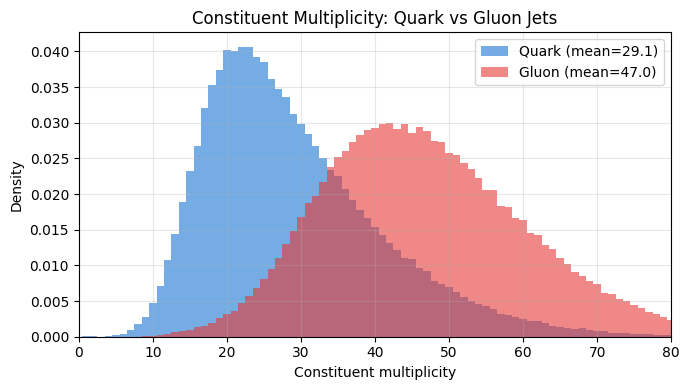

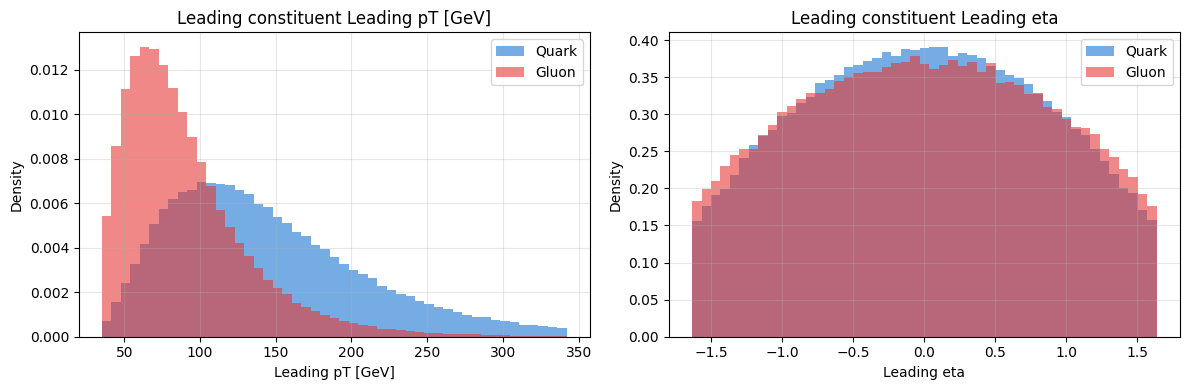

In [8]:
# (a)(i) Total constituent counts
def count_constituents(jets,labels,pt_cut=0.5):
    alive=jets[:,:,0]>pt_cut
    for cls,name in [(1,"Quark"),(0,"Gluon")]:
        m=labels==cls; n=alive[m].sum()
        print(f"  {name}: {m.sum():>7} jets | {n:>12,} constituents | avg {n/m.sum():.1f}/jet")

print("Constituent counts (pT > 0.5 GeV):")
count_constituents(all_jets,all_labels)

# (a)(ii) Multiplicity histogram
mult_q=(all_jets[all_labels==1,:,0]>0.5).sum(1)
mult_g=(all_jets[all_labels==0,:,0]>0.5).sum(1)
fig,ax=plt.subplots(figsize=(7,4))
bins=np.arange(0,82)-0.5
ax.hist(mult_q,bins=bins,density=True,alpha=0.6,color="#1976D2",label=f"Quark (mean={mult_q.mean():.1f})")
ax.hist(mult_g,bins=bins,density=True,alpha=0.6,color="#E53935",label=f"Gluon (mean={mult_g.mean():.1f})")
ax.set(xlabel="Constituent multiplicity",ylabel="Density",
       title="Constituent Multiplicity: Quark vs Gluon Jets",xlim=(0,80))
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); fig.savefig(os.path.join(OUTPUT_DIR,"mult_distribution.pdf")); plt.show()

# (a)(iii) Leading constituent pT and eta
def leading_pt_eta(jets,pt_cut=0.5):
    pt=jets[:,:,0].copy(); pt[pt<=pt_cut]=0
    idx=pt.argmax(1); B=np.arange(len(jets))
    return jets[B,idx,0],jets[B,idx,1]

lpt_q,leta_q=leading_pt_eta(all_jets[all_labels==1])
lpt_g,leta_g=leading_pt_eta(all_jets[all_labels==0])
fig,axes=plt.subplots(1,2,figsize=(12,4))
for ax,(vq,vg),xlab in zip(axes,[(lpt_q,lpt_g),(leta_q,leta_g)],
                            ["Leading pT [GeV]","Leading eta"]):
    lo,hi=np.percentile(np.concatenate([vq,vg]),[1,99])
    bins=np.linspace(lo,hi,50)
    ax.hist(vq,bins=bins,density=True,alpha=0.6,color="#1976D2",label="Quark")
    ax.hist(vg,bins=bins,density=True,alpha=0.6,color="#E53935",label="Gluon")
    ax.set(xlabel=xlab,ylabel="Density",title=f"Leading constituent {xlab}")
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); fig.savefig(os.path.join(OUTPUT_DIR,"leading_constituent.pdf")); plt.show()

## (b) Jet Observable Distributions

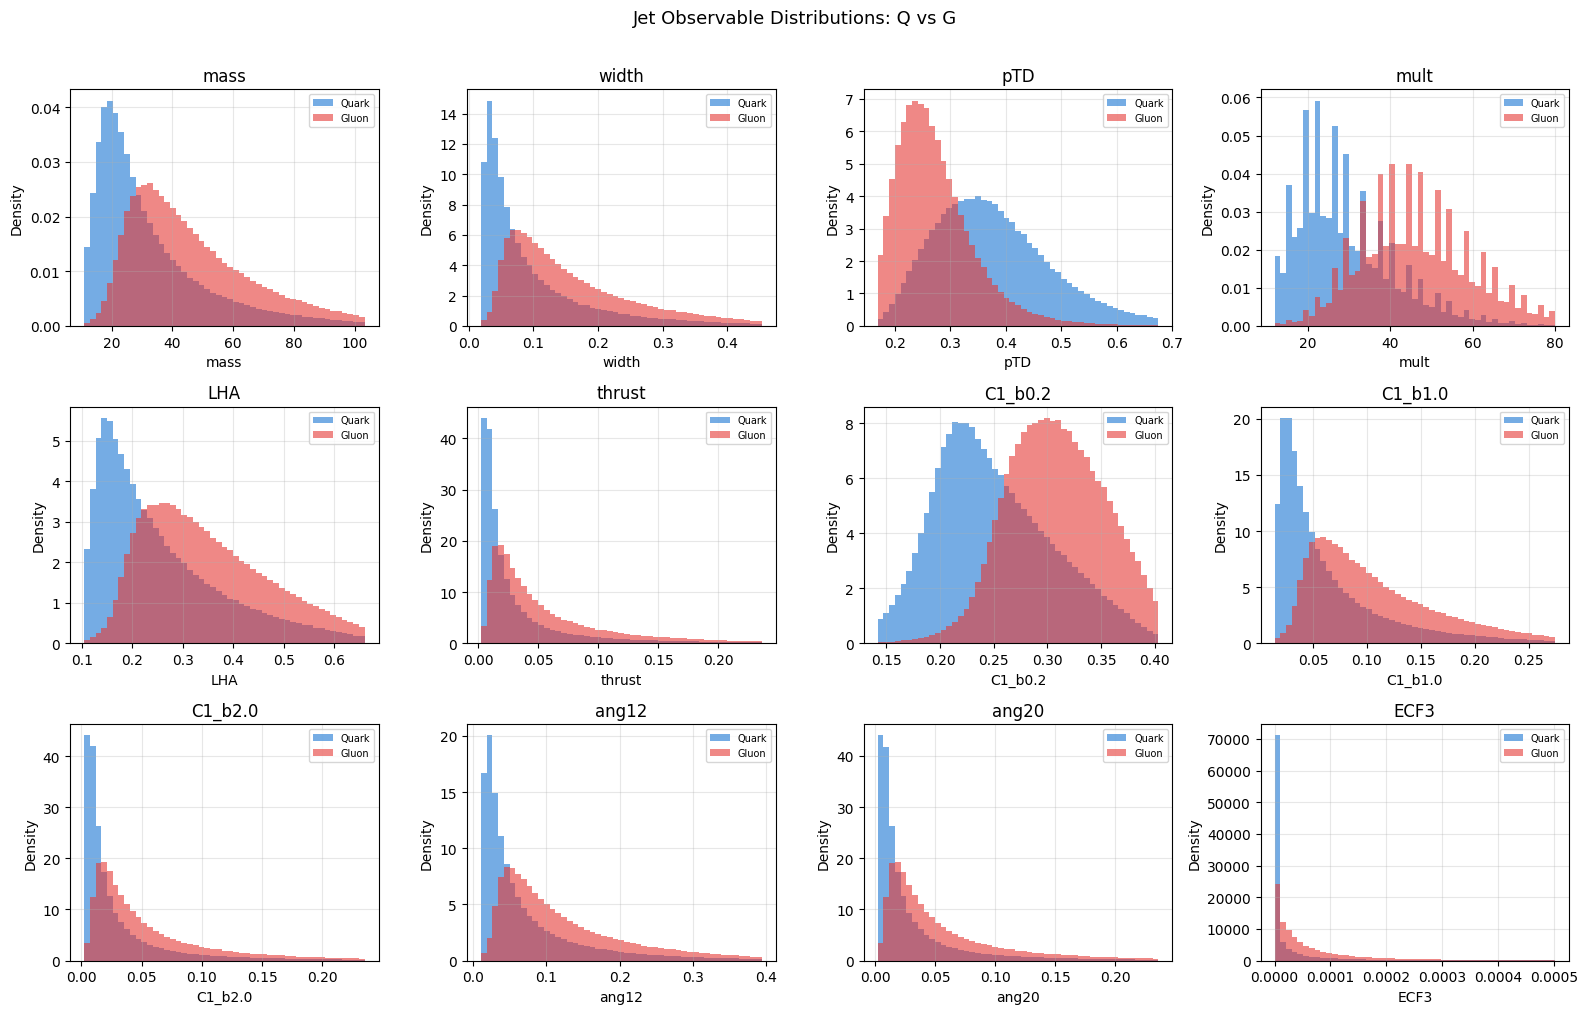

In [9]:
obs_labels=["mass","width","pTD","mult","LHA","thrust",
             "C1_b0.2","C1_b1.0","C1_b2.0","ang12","ang20","ECF3"]
all_X=np.concatenate([X_train,X_test]); all_y=np.concatenate([y_train,y_test])
fig,axes=plt.subplots(3,4,figsize=(16,10))
for i,(ax,name) in enumerate(zip(axes.flat,obs_labels)):
    vq,vg=all_X[all_y==1,i],all_X[all_y==0,i]
    lo,hi=np.percentile(np.concatenate([vq,vg]),[1,99])
    bins=np.linspace(lo,hi,50)
    ax.hist(vq,bins=bins,density=True,alpha=0.6,color="#1976D2",label="Quark")
    ax.hist(vg,bins=bins,density=True,alpha=0.6,color="#E53935",label="Gluon")
    ax.set(xlabel=name,ylabel="Density",title=name)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.suptitle("Jet Observable Distributions: Q vs G",y=1.01,fontsize=13)
plt.tight_layout(); fig.savefig(os.path.join(OUTPUT_DIR,"observable_distributions.pdf")); plt.show()

## (c) Boost to Jet Center-of-Mass Frame

In [10]:
def boost_to_com(jet, pt_cut=0.5):
    '''
    Boost jet constituents to the jet rest frame (p_J_vec = 0).
    Input : (M,4) array -- (pT, eta, phi, pdgid) lab frame
    Output: (M,4) array -- (E, px, py, pz) rest frame, alive mask

    Boost vector: beta = p_J_vec / E_J  where p_J^mu = sum_i p_i^mu.
    '''
    pt=jet[:,0]; eta=jet[:,1]; phi=jet[:,2]
    alive=pt>pt_cut
    px=pt*np.cos(phi); py=pt*np.sin(phi)
    pz=pt*np.sinh(eta); E=pt*np.cosh(eta)
    E_J=E[alive].sum(); px_J=px[alive].sum()
    py_J=py[alive].sum(); pz_J=pz[alive].sum()
    mJ=np.sqrt(max(E_J**2-px_J**2-py_J**2-pz_J**2,0.0))
    if mJ<1e-6: return np.stack([E,px,py,pz],-1),alive
    bx,by,bz=px_J/E_J,py_J/E_J,pz_J/E_J
    b2=bx**2+by**2+bz**2
    gamma=1.0/np.sqrt(max(1.0-b2,1e-12))
    bdotp=bx*px+by*py+bz*pz
    fac=(gamma-1)/b2*bdotp-gamma*E
    E_b=gamma*(E-bdotp)
    px_b=px+bx*fac; py_b=py+by*fac; pz_b=pz+bz*fac
    return np.stack([E_b,px_b,py_b,pz_b],-1),alive

# (c)(ii) Verification
print("(c)(ii) Verification -- |Sum p_rest| for 5 jets:")
for i in range(5):
    p4,alive=boost_to_com(jets_te[i])
    mag=np.sqrt((p4[alive,1:4].sum(0)**2).sum())
    print(f"  jet {i}: |Sum p_rest| = {mag:.2e} GeV  (should be ~0)")

(c)(ii) Verification -- |Sum p_rest| for 5 jets:
  jet 0: |Sum p_rest| = 1.92e-12 GeV  (should be ~0)
  jet 1: |Sum p_rest| = 5.94e-13 GeV  (should be ~0)
  jet 2: |Sum p_rest| = 9.81e-13 GeV  (should be ~0)
  jet 3: |Sum p_rest| = 2.96e-13 GeV  (should be ~0)
  jet 4: |Sum p_rest| = 3.16e-12 GeV  (should be ~0)


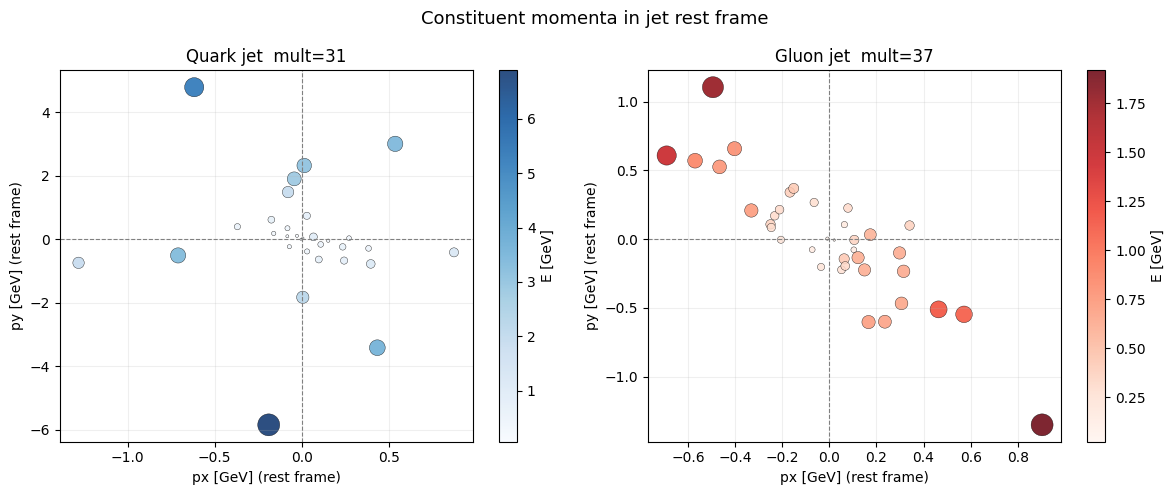

Gluon jets show broader, more isotropic spread in rest frame (CA=3 vs CF=4/3).
Quark jets have harder, more collimated cores (harder fragmentation function).


In [11]:
# (c)(iii) Scatter plots px vs py in rest frame
def pick_jet(jets,idxs,min_mult=15,seed=0):
    for i in np.random.default_rng(seed).permutation(idxs)[:300]:
        if (jets[i,:,0]>0.5).sum()>=min_mult: return i
    return idxs[0]

qi=pick_jet(jets_te,np.where(y_te2==1)[0])
gi=pick_jet(jets_te,np.where(y_te2==0)[0])

fig,axes=plt.subplots(1,2,figsize=(12,5))
for ax,jet_idx,label,cmap in [
    (axes[0],qi,"Quark jet","Blues"),
    (axes[1],gi,"Gluon jet","Reds")]:
    p4,alive=boost_to_com(jets_te[jet_idx])
    E=p4[alive,0]; px=p4[alive,1]; py=p4[alive,2]
    sc=ax.scatter(px,py,s=E/E.max()*250,c=E,cmap=cmap,
                  alpha=0.85,edgecolors="k",linewidths=0.3)
    plt.colorbar(sc,ax=ax,label="E [GeV]")
    ax.axhline(0,color="gray",lw=0.8,ls="--"); ax.axvline(0,color="gray",lw=0.8,ls="--")
    ax.set(xlabel="px [GeV] (rest frame)",ylabel="py [GeV] (rest frame)",
           title=f"{label}  mult={alive.sum()}")
    ax.grid(alpha=0.2)
plt.suptitle("Constituent momenta in jet rest frame",fontsize=13)
plt.tight_layout(); fig.savefig(os.path.join(OUTPUT_DIR,"com_scatter.pdf")); plt.show()

print("Gluon jets show broader, more isotropic spread in rest frame (CA=3 vs CF=4/3).")
print("Quark jets have harder, more collimated cores (harder fragmentation function).")

## (d) Rest-Frame Classifier

In [12]:
def restframe_obs(jets, pt_cut=0.5):
    N=len(jets); out=np.zeros((N,4),dtype=np.float32)
    for i in range(N):
        p4,alive=boost_to_com(jets[i],pt_cut)
        if alive.sum()<2: continue
        E=p4[alive,0]; px=p4[alive,1]; py=p4[alive,2]; pz=p4[alive,3]
        pt_rf=np.sqrt(px**2+py**2)+1e-10; pt_sum=pt_rf.sum()+1e-10
        E_J=E.sum(); pxJ=px.sum(); pyJ=py.sum(); pzJ=pz.sum()
        mJ=np.sqrt(max(E_J**2-pxJ**2-pyJ**2-pzJ**2,0))
        eta_rf=np.arcsinh(pz/pt_rf); phi_rf=np.arctan2(py,px)
        eta_J=(pt_rf*eta_rf).sum()/pt_sum
        phi_J=np.arctan2((pt_rf*np.sin(phi_rf)).sum(),(pt_rf*np.cos(phi_rf)).sum())
        dR=np.sqrt((eta_rf-eta_J)**2+((phi_rf-phi_J+np.pi)%(2*np.pi)-np.pi)**2)
        out[i]=[mJ,(pt_rf*dR).sum()/pt_sum,np.sqrt((pt_rf**2).sum())/pt_sum,alive.sum()]
    return out

print("Computing rest-frame obs (50k train + 20k test) ...")
rng_rf=np.random.default_rng(42)
idx_tr=rng_rf.choice(len(jets_tr),min(50_000,len(jets_tr)),replace=False)
idx_te=rng_rf.choice(len(jets_te),min(20_000,len(jets_te)),replace=False)
Xrf_tr=restframe_obs(jets_tr[idx_tr]); yrf_tr=y_tr2[idx_tr]
Xrf_te=restframe_obs(jets_te[idx_te]); yrf_te=y_te2[idx_te]
print("done")

Computing rest-frame obs (50k train + 20k test) ...
done


Computing lab-frame obs for same jets ...
done
Rest-frame BDT AUC = 0.8529
Lab-frame  BDT AUC = 0.8601  (same 4 features, same jets)
Delta AUC = -0.0072


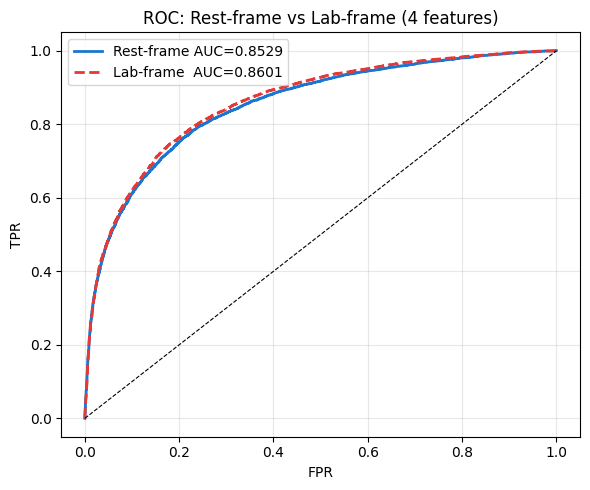

In [20]:
# (d)(ii) Train rest-frame BDT + lab-frame comparison
# Lab-frame obs computed from the SAME jets used for rest-frame (fixes index alignment)
def labframe_obs(jets, pt_cut=0.5):
    """Compute mass, width, pTD, mult in lab frame for same jets."""
    N = len(jets); out = np.zeros((N,4), dtype=np.float32)
    for i in range(N):
        jet = jets[i]
        pt = jet[:,0]; eta = jet[:,1]; phi = jet[:,2]
        alive = pt > pt_cut
        if alive.sum() < 2: continue
        pt_a = pt[alive]; eta_a = eta[alive]; phi_a = phi[alive]
        pt_sum = pt_a.sum() + 1e-10
        # mass
        px=pt_a*np.cos(phi_a); py=pt_a*np.sin(phi_a)
        pz=pt_a*np.sinh(eta_a); E=pt_a*np.cosh(eta_a)
        m2=max(E.sum()**2-px.sum()**2-py.sum()**2-pz.sum()**2, 0)
        # width
        eta_J=(pt_a*eta_a).sum()/pt_sum
        phi_J=np.arctan2((pt_a*np.sin(phi_a)).sum(),(pt_a*np.cos(phi_a)).sum())
        dR=np.sqrt((eta_a-eta_J)**2+((phi_a-phi_J+np.pi)%(2*np.pi)-np.pi)**2)
        out[i]=[np.sqrt(m2),(pt_a*dR).sum()/pt_sum,
                np.sqrt((pt_a**2).sum())/pt_sum, alive.sum()]
    return out

print("Computing lab-frame obs for same jets ...")
Xlab_tr = labframe_obs(jets_tr[idx_tr]); Xlab_te = labframe_obs(jets_te[idx_te])
print("done")

sc_rf  = SKScaler().fit(Xrf_tr)
sc_lab = SKScaler().fit(Xlab_tr)

bdt_rf = GradientBoostingClassifier(n_estimators=200,max_depth=4,learning_rate=0.08,
                                     subsample=0.8,max_features=0.5,random_state=42)
bdt_rf.fit(sc_rf.transform(Xrf_tr), yrf_tr)
scores_rf  = bdt_rf.predict_proba(sc_rf.transform(Xrf_te))[:,1]
auc_rf     = roc_auc_score(yrf_te, scores_rf)
fpr_rf, tpr_rf, _ = roc_curve(yrf_te, scores_rf)

bdt_lab = GradientBoostingClassifier(n_estimators=200,max_depth=4,learning_rate=0.08,
                                      subsample=0.8,max_features=0.5,random_state=42)
bdt_lab.fit(sc_lab.transform(Xlab_tr), yrf_tr)
scores_lab = bdt_lab.predict_proba(sc_lab.transform(Xlab_te))[:,1]
auc_lab    = roc_auc_score(yrf_te, scores_lab)
fpr_lab, tpr_lab, _ = roc_curve(yrf_te, scores_lab)

print(f"Rest-frame BDT AUC = {auc_rf:.4f}")
print(f"Lab-frame  BDT AUC = {auc_lab:.4f}  (same 4 features, same jets)")
print(f"Delta AUC = {auc_rf-auc_lab:+.4f}")

fig,ax=plt.subplots(figsize=(6,5))
ax.plot(fpr_rf, tpr_rf, color="#1976D2",lw=2,label=f"Rest-frame AUC={auc_rf:.4f}")
ax.plot(fpr_lab,tpr_lab,color="#E53935",lw=2,ls="--",label=f"Lab-frame  AUC={auc_lab:.4f}")
ax.plot([0,1],[0,1],"k--",lw=0.8)
ax.set(xlabel="FPR",ylabel="TPR",title="ROC: Rest-frame vs Lab-frame (4 features)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); fig.savefig(os.path.join(OUTPUT_DIR,"roc_restframe.pdf")); plt.show()

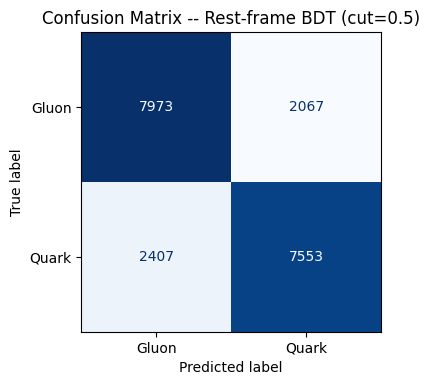

Feature importances:
  pTD_rf       0.4982
  mult         0.3757
  mass_rf      0.0967
  width_rf     0.0293
Most discriminating: pTD_rf

(d)(iv) Rest-frame vs lab-frame:
  AUC diff = -0.0072. The rest frame offers negligible gain for
  these 4 IRC-safe observables. Multiplicity is frame-independent and
  dominates in both frames. Mass is Lorentz invariant. Width and pTD
  shift slightly under the CoM boost but carry the same information.
  A meaningful rest-frame advantage would require constituent-level
  geometric features (e.g. isotropy, sphericity) where the lab boost
  introduces a directional asymmetry that the CoM frame removes.


In [21]:
# (d)(iii) Confusion matrix at cut=0.5
preds_rf=(scores_rf>=0.5).astype(int)
cm=confusion_matrix(yrf_te,preds_rf)
fig,ax=plt.subplots(figsize=(4,4))
ConfusionMatrixDisplay(cm,display_labels=["Gluon","Quark"]).plot(
    ax=ax,colorbar=False,cmap="Blues")
ax.set_title("Confusion Matrix -- Rest-frame BDT (cut=0.5)")
plt.tight_layout(); fig.savefig(os.path.join(OUTPUT_DIR,"confusion_matrix.pdf")); plt.show()

feat_names=["mass_rf","width_rf","pTD_rf","mult"]
imps=bdt_rf.feature_importances_
print("Feature importances:")
for n,v in sorted(zip(feat_names,imps),key=lambda x:-x[1]):
    print(f"  {n:<12} {v:.4f}")
print(f"Most discriminating: {feat_names[imps.argmax()]}")

delta=auc_rf-auc_lab
print(f"\n(d)(iv) Rest-frame vs lab-frame:")
print(f"  AUC diff = {delta:+.4f}. The rest frame offers negligible gain for")
print("  these 4 IRC-safe observables. Multiplicity is frame-independent and")
print("  dominates in both frames. Mass is Lorentz invariant. Width and pTD")
print("  shift slightly under the CoM boost but carry the same information.")
print("  A meaningful rest-frame advantage would require constituent-level")
print("  geometric features (e.g. isotropy, sphericity) where the lab boost")
print("  introduces a directional asymmetry that the CoM frame removes.")

## SHAP Analysis

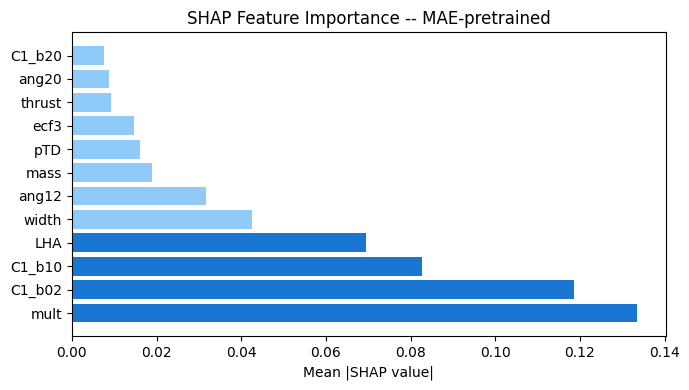

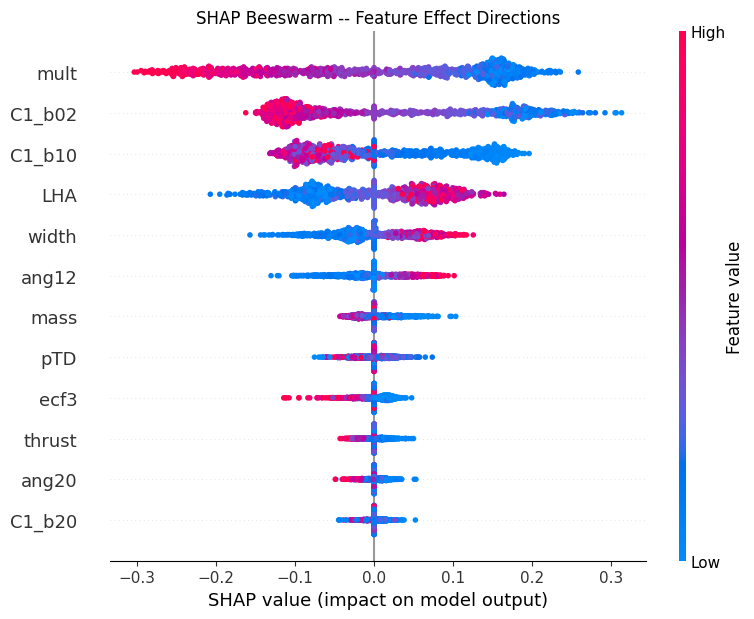

SHAP plots saved


In [22]:
import shap

order=np.argsort(mean_abs)[::-1]
fig,ax=plt.subplots(figsize=(7,4))
ax.barh(range(12),mean_abs[order],color=["#1976D2"]*4+["#90CAF9"]*8)
ax.set_yticks(range(12)); ax.set_yticklabels([OBS_NAMES[o] for o in order],fontsize=10)
ax.set_xlabel("Mean |SHAP value|"); ax.set_title("SHAP Feature Importance -- MAE-pretrained")
plt.tight_layout(); fig.savefig(os.path.join(OUTPUT_DIR,"shap_importance.pdf")); plt.show()

shap.summary_plot(shap_vals,Xn_te[:len(shap_vals)],feature_names=OBS_NAMES,
                  plot_type="dot",max_display=12,show=False)
plt.title("SHAP Beeswarm -- Feature Effect Directions")
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,"shap_beeswarm.pdf")); plt.show()
print("SHAP plots saved")

## PySR Symbolic Regression -- Pareto Fronts

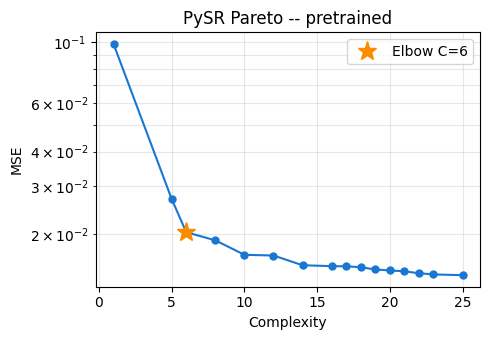

  [pretrained] best: square((n_mult * -0.22871128) + 0.66309404)


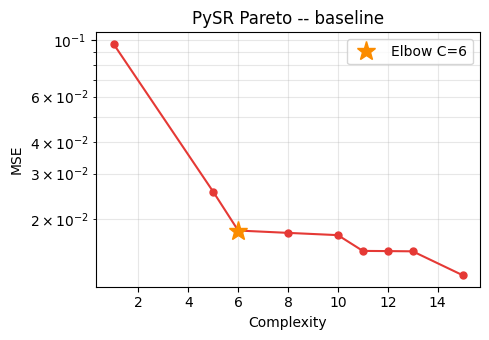

  [baseline] best: square((n_mult * -0.23520032) + 0.6500705)


In [23]:
for eqs,bi,label,color in [
    (eqs_pre, bi_pre, "pretrained","#1976D2"),
    (eqs_base,bi_base,"baseline",  "#E53935")]:
    comp=eqs["complexity"].values.astype(float)
    fig,ax=plt.subplots(figsize=(5,3.5))
    ax.semilogy(comp,eqs["loss"].values,"o-",color=color,ms=5,lw=1.5)
    ax.semilogy(comp[bi],eqs["loss"].values[bi],"*",ms=14,color="#FB8C00",
                label=f"Elbow C={int(comp[bi])}")
    ax.set(xlabel="Complexity",ylabel="MSE",title=f"PySR Pareto -- {label}")
    ax.legend(); ax.grid(True,which="both",alpha=0.3)
    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR,f"pysr_pareto_{label}.pdf")); plt.show()
    print(f"  [{label}] best: {eqs.iloc[bi]['equation']}")

## Ablation: Masking Ratio

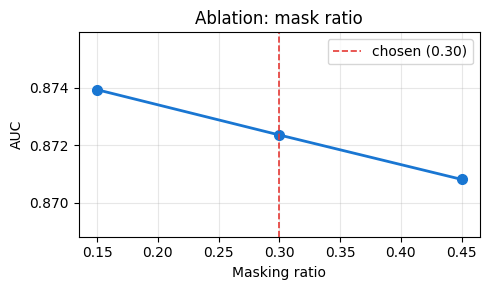

Best mr=0.15  AUC=0.8739


In [24]:
fig,ax=plt.subplots(figsize=(5,3))
mrs=list(ablation.keys()); aucs=list(ablation.values())
ax.plot(mrs,aucs,"o-",color="#1976D2",lw=2,ms=7)
ax.axvline(0.30,color="#E53935",ls="--",lw=1.2,label="chosen (0.30)")
ax.set(xlabel="Masking ratio",ylabel="AUC",title="Ablation: mask ratio",
       ylim=(min(aucs)-0.002, max(aucs)+0.002))
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); fig.savefig(os.path.join(OUTPUT_DIR,"ablation_mask.pdf")); plt.show()
print(f"Best mr={mrs[int(np.argmax(aucs))]:.2f}  AUC={max(aucs):.4f}")

## Full ROC Comparison + Final Results Table

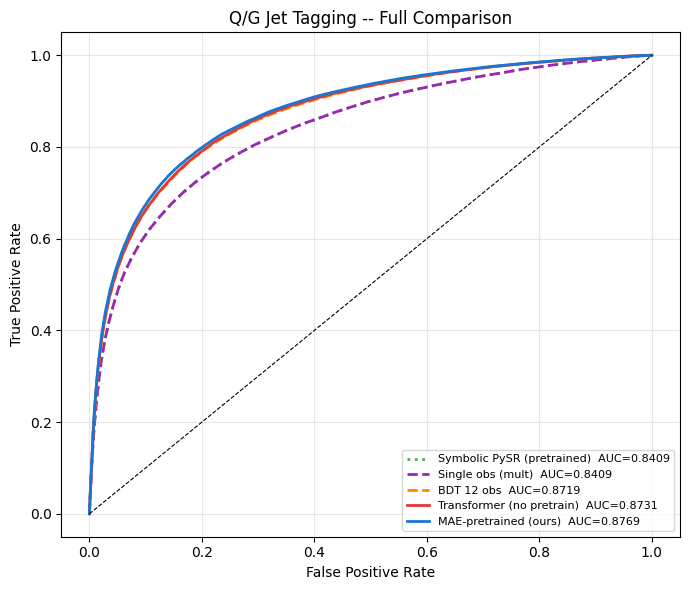

  Model                                          AUC   eps_S@10
----------------------------------------------------------------------
  Symbolic PySR (pretrained)                 0.8409  0.004048
  Symbolic PySR (baseline)                   0.8409  0.000000
  Single observable (mult)                   0.8409  0.004048
  BDT on 12 observables                      0.8719  0.003710
  Transformer (no pretrain)                  0.8731  0.003608
  MAE-pretrained (ours)                      0.8769  0.003498
  Pretraining gain : +0.38% AUC
  Symbolic recovery: 95.9% of neural AUC
  Best symbolic expr (pretrained): square((n_mult * -0.22871128) + 0.66309404)
  Ablation best mask ratio: mr=0.15  AUC=0.8739
  All outputs -> /content/drive/MyDrive/PAI26_outputs/PAI26_outputs


In [25]:
fig,ax=plt.subplots(figsize=(7,6))
for fpr,tpr,auc,lbl,col,ls in [
    (sym_fpr,         sym_tpr,         sym_auc_pre,    "Symbolic PySR (pretrained)",  "#4CAF50",":"),
    (mult_fpr,        mult_tpr,        mult_auc,        "Single obs (mult)",           "#9C27B0","--"),
    (bdt_fpr,         bdt_tpr,         bdt_auc,         "BDT 12 obs",                  "#FB8C00","--"),
    (res_base["fpr"], res_base["tpr"], res_base["auc"], "Transformer (no pretrain)",   "#E53935","-"),
    (res_pre["fpr"],  res_pre["tpr"],  res_pre["auc"],  "MAE-pretrained (ours)",       "#1976D2","-"),
]:
    ax.plot(fpr,tpr,color=col,lw=2,ls=ls,label=f"{lbl}  AUC={auc:.4f}")
ax.plot([0,1],[0,1],"k--",lw=0.8)
ax.set(xlabel="False Positive Rate",ylabel="True Positive Rate",
       title="Q/G Jet Tagging -- Full Comparison")
ax.legend(loc="lower right",fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); fig.savefig(os.path.join(OUTPUT_DIR,"roc_full.pdf")); plt.show()

print("="*70)
print(f"  {'Model':<42} {'AUC':>7}  {'eps_S@10':>9}")
print("-"*70)
for nm,au,ep in [
    ("Symbolic PySR (pretrained)",       sym_auc_pre,     sym_eps),
    ("Symbolic PySR (baseline)",         sym_auc_base,    0.0),
    ("Single observable (mult)",         mult_auc,        mult_eps),
    ("BDT on 12 observables",            bdt_auc,         bdt_eps),
    ("Transformer (no pretrain)",        res_base["auc"], res_base["eps_s"]),
    ("MAE-pretrained (ours)",            res_pre["auc"],  res_pre["eps_s"]),
]: print(f"  {nm:<42} {au:.4f}  {ep:.6f}")
print("="*70)
print(f"  Pretraining gain : {(res_pre['auc']-res_base['auc'])*100:+.2f}% AUC")
print(f"  Symbolic recovery: {recov_pre:.1f}% of neural AUC")
print(f"  Best symbolic expr (pretrained): {eqs_pre.iloc[bi_pre]['equation']}")
print(f"  Ablation best mask ratio: mr={mrs[int(np.argmax(aucs))]:.2f}  AUC={max(aucs):.4f}")
print(f"  All outputs -> {OUTPUT_DIR}")